<a href="https://colab.research.google.com/github/jesse-kariuki/Data-Wrangling/blob/main/Airplane_Crashes_Data_Cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving Airplane_Crashes_and_Fatalities_Since_1908.csv to Airplane_Crashes_and_Fatalities_Since_1908 (2).csv


In [ ]:
import pandas as pd
import numpy as np
df = pd.read_csv("Airplane_Crashes_and_Fatalities_Since_1908.csv")

In [ ]:
rows,cols = df.shape

print("Rows: ", rows)
print("Columns: ", cols)

Rows:  5268
Columns:  13


In [43]:
print("Last 75 rows: ", df.tail(75))

Last 75 rows:              Date   Time                                           Location  \
5193  03/15/2008  08:15                                     Nbagu, Nigeria   
5194  04/03/2008  11:00                                     Lawa, Suriname   
5195  04/09/2008  23:27                                Bundeena, Australia   
5196  04/11/2008  22:15                                 Chrisinau, Moldova   
5197  04/15/2008  14:30                                        Goma, Congo   
...          ...    ...                                                ...   
5263  05/20/2009  06:30                             Near Madiun, Indonesia   
5264  05/26/2009    NaN                  Near Isiro, DemocratiRepubliCongo   
5265  06/01/2009  00:15  AtlantiOcean, 570 miles northeast of Natal, Br...   
5266  06/07/2009  08:30       Near Port Hope Simpson, Newfoundland, Canada   
5267  06/08/2009    NaN                  State of Arunachal Pradesh, India   

                             Operator Flight #  

In [ ]:
df.describe()

,Aboard,Fatalities,Ground
count,5246.000000,5256.000000,5246.000000
mean,27.554518,20.068303,1.608845
std,43.076711,33.199952,53.987827
min,0.000000,0.000000,0.000000
25%,5.000000,3.000000,0.000000
50%,13.000000,9.000000,0.000000
75%,30.000000,23.000000,0.000000
max,644.000000,583.000000,2750.000000


In [ ]:
"""
1. Time - Using the mode since time cannot be reliably reconstructed from other means
2. Location - Leaving it as "Unknown" since guessing a location will lead to false information
3. Operator - Using mode (most ocurring) operator since it's categorical data, it cannot be guessed via mean and mode
4. Flight number - Leave as "Unknown" since it cannot be assumed reliably. It is a mix of textual and numeric data so leaving as 0 or mode/mean/median is unreliable
5. Route - "Unknown" since it contains text data that cannot be reconstructed from other means
6. Type - Can be "Unknown" or mode since the most ocurring type can be used to guess the types for the missing values
7. Registration - Using "Unknown" or leaving it blank since the registration serves as a unique identifier and other methods would be inappropriate
8. cn/in - Since it is a unique identifier, leave it as blank
9. Aboard - Median as it's numeric and it is least affected by extremeties like the mean
10. Fatalities - Median since it's a numeric value and not affected by outliers like mean
11. Ground - Leave them as 0, as it's supported in the column
12. Summary - Leave blank as they are textual data that cannot be guessed
"""

'\n1. Time - Using the mode since time cannot be reliably reconstructed from other means\n2. Location - Leaving it as "Unknown" since guessing a location will lead to false information\n3. Operator - Using mode (most ocurring) operator since it\'s categorical data, it cannot be guessed via mean and mode\n4. Flight number - Leave as "Unknown" since it cannot be assumed reliably. It is a mix of textual and numeric data so leaving as 0 or mode/mean/median is unreliable\n5. Route - "Unknown" since it contains text data that cannot be reconstructed from other means\n6. Type - Can be "Unknown" or mode since the most ocurring type can be used to guess the types for the missing values\n7.\n'

In [ ]:
df['Flight #']

,Flight #
0,NaN
1,NaN
2,-
3,NaN
4,NaN
...,...
5263,NaN
5264,NaN
5265,447
5266,NaN


In [ ]:
fatality_locations = df[['Date', 'Location', 'Aboard', 'Fatalities']].copy()
fatality_locations.head()

,Date,Location,Aboard,Fatalities
0,09/17/1908,"Fort Myer, Virginia",2.0,1.0
1,07/12/1912,"AtlantiCity, New Jersey",5.0,5.0
2,08/06/1913,"Victoria, British Columbia, Canada",1.0,1.0
3,09/09/1913,Over the North Sea,20.0,14.0
4,10/17/1913,"Near Johannisthal, Germany",30.0,30.0


In [ ]:
max_fatalities = fatality_locations['Fatalities'].max()
max_fatalities

583.0

In [ ]:
max_ind = fatality_locations['Fatalities'].idxmax()
print(fatality_locations.loc[max_ind, 'Date'])


03/27/1977


In [ ]:
fatality_locations[(fatality_locations['Aboard'] > 0) & (fatality_locations['Fatalities'] == 0)]

,Date,Location,Aboard,Fatalities
108,10/21/1926,English Channel,12.0,0.0
387,03/05/1936,"Near Tengya, China",6.0,0.0
889,10/08/1947,"Near El Paso, Texas",54.0,0.0
897,11/11/1947,"Gallup, New Mexico",25.0,0.0
1265,05/25/1953,"Amsterdam, Netherlands",34.0,0.0
1359,01/19/1955,"Des Moines, Iowa",39.0,0.0
1440,09/09/1956,"Bartlesville, Oklahoma",18.0,0.0
1443,10/16/1956,Over the PacifiOcean,31.0,0.0
1610,06/30/1959,"Ishikawa City, Ryukyu Island, Okinawa",1.0,0.0
1837,02/28/1963,"Boston, Massachusetts",26.0,0.0


In [ ]:
fatality_locations[['Region', 'State/Country']] = (fatality_locations['Location'].str.rsplit(',', n=1, expand = True))

In [ ]:
fatality_locations[
    ['Location', 'Region', 'State/Country']
].head(20)

,Location,Region,State/Country
0,"Fort Myer, Virginia",Fort Myer,Virginia
1,"AtlantiCity, New Jersey",AtlantiCity,New Jersey
2,"Victoria, British Columbia, Canada","Victoria, British Columbia",Canada
3,Over the North Sea,Over the North Sea,None
4,"Near Johannisthal, Germany",Near Johannisthal,Germany
5,"Tienen, Belgium",Tienen,Belgium
6,"Off Cuxhaven, Germany",Off Cuxhaven,Germany
7,"Near Jambol, Bulgeria",Near Jambol,Bulgeria
8,"Billericay, England",Billericay,England
9,"Potters Bar, England",Potters Bar,England


In [ ]:
top_100 = fatality_locations.sort_values(by='Fatalities', ascending=False).head(100)

top_100

,Date,Location,Aboard,Fatalities,Region,State/Country
2963,03/27/1977,"Tenerife, Canary Islands",644.0,583.0,Tenerife,Canary Islands
3568,08/12/1985,"Mt. Osutaka, near Ueno Village, Japan",524.0,520.0,"Mt. Osutaka, near Ueno Village",Japan
4455,11/12/1996,"Near Charkhidadri, India",349.0,349.0,Near Charkhidadri,India
2726,03/03/1974,"Near Ermenonville, France",346.0,346.0,Near Ermenonville,France
3562,06/23/1985,"AtlantiOcean, 110 miles West of Ireland",329.0,329.0,AtlantiOcean,110 miles West of Ireland
...,...,...,...,...,...,...
4852,04/15/2002,"Busan, South Korea",166.0,128.0,Busan,South Korea
3198,01/21/1980,"Elburz Mtns., near Laskarak, Markazi, Iran",128.0,128.0,"Elburz Mtns., near Laskarak, Markazi",Iran
1701,12/16/1960,"Staten Island / Brooklyn, New York",128.0,128.0,Staten Island / Brooklyn,New York
5108,07/09/2006,"Irkutsk, Russia",203.0,128.0,Irkutsk,Russia


In [ ]:
country_fatalities = (fatality_locations
    .groupby('State/Country')['Fatalities']
    .sum()
    .sort_values(ascending=False)
)

top_25 = country_fatalities.head(25)

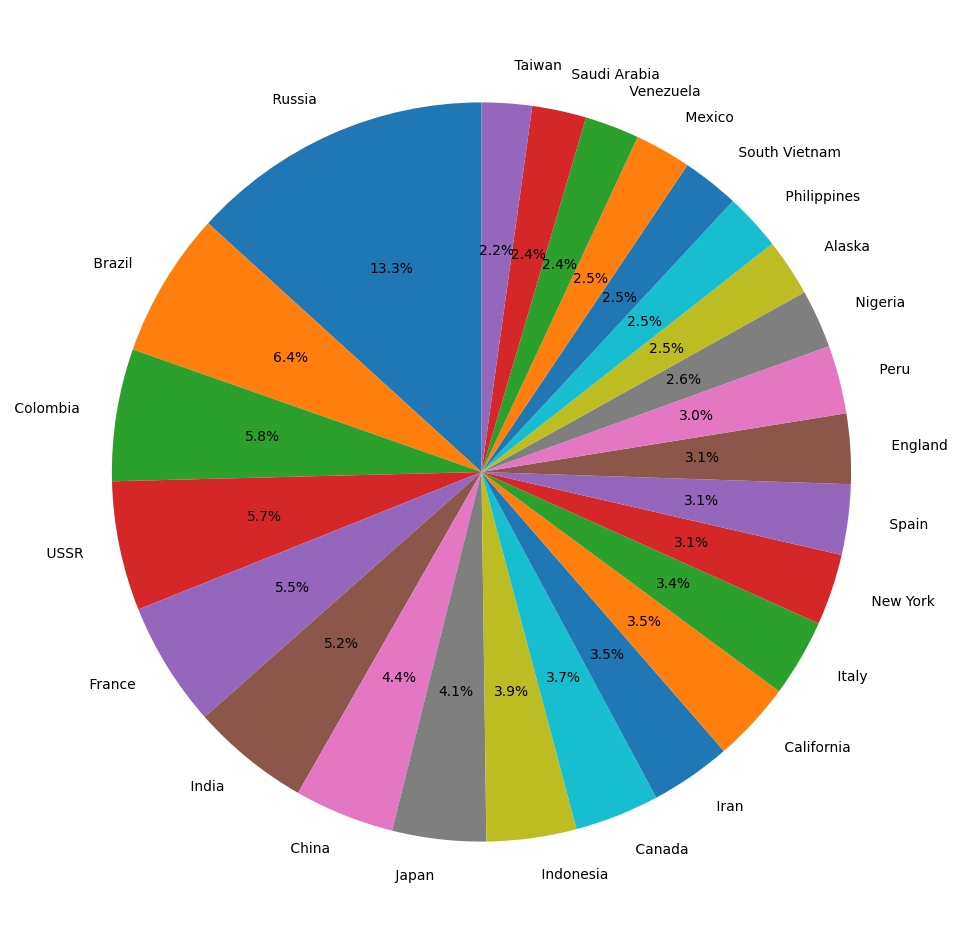

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 12))

plt.pie(top_25, labels=top_25.index, autopct='%1.1f%%', startangle=90)

plt.show()